In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# SD/CN dependencies
!pip install --upgrade diffusers transformers accelerate safetensors torch torchvision torchaudio numpy scipy pillow opencv-python matplotlib tqdm einops omegaconf huggingface_hub ftfy sentencepiece xformers controlnet_aux opencv-python image_reward

In [ ]:
# Import all required libraries
import torch
from diffusers import StableDiffusionXLControlNetPipeline, StableDiffusionControlNetPipeline, ControlNetModel, ControlNetUnionModel, StableDiffusionXLControlNetUnionPipeline
from transformers import CLIPImageProcessor
from PIL import Image
import numpy as np
import cv2

# Free Memory
torch.cuda.empty_cache()

In [ ]:
# Set up processing device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Allocate paths
image_render_path = "/content/drive/MyDrive/inputs/Render.png"
image_normal_path = "/content/drive/MyDrive/inputs/NormalMap.png"
image_depth_path = "/content/drive/MyDrive/inputs/DepthMap.png"
image_albedo_path = "/content/drive/MyDrive/inputs/AlbedoMap.png"
image_shadow_path = "/content/drive/MyDrive/inputs/ShadowMap.png"
image_refract_path = "/content/drive/MyDrive/inputs/RefractionMapAlt.png"

In [ ]:
# ControlNet Union with SDXL
controlnet_u = ControlNetUnionModel.from_pretrained("xinsir/controlnet-union-sdxl-1.0", torch_dtype=torch.float16)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ControlNet setup (FOR SD 1.5)
# Load available ControlNet models
controlnet_canny = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
controlnet_depth = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16)
controlnet_normal = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-normal", torch_dtype=torch.float16)
controlnet_segment = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-seg", torch_dtype=torch.float16)
# Form Multi-ControlNet
controlnets = MultiControlNetModel([controlnet_canny, controlnet_depth, controlnet_normal, controlnet_canny, controlnet_canny, controlnet_segment])

In [ ]:
# ControlNet SDXL
cnxl_canny = ControlNetModel.from_pretrained("xinsir/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16)
cnxl_depth = ControlNetModel.from_pretrained("xinsir/controlnet-depth-sdxl-1.0", torch_dtype=torch.float16)
cnxl_tile = ControlNetModel.from_pretrained("xinsir/controlnet-tile-sdxl-1.0", torch_dtype=torch.float16)

cnxlnets = ControlNetUnionModel([cnxl_canny, cnxl_depth, cnxl_tile, cnxl_tile])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

TypeError: unsupported operand type(s) for %: 'list' and 'int'

In [ ]:
# Load ControlNet
# either runwayml/stable-diffusion-v1-5 or stabilityai/stable-diffusion-xl-base-1.0
pipeln = StableDiffusionXLControlNetUnionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", controlnet=controlnet_u, torch_dtype=torch.float16).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
# Load image
main_render = Image.open(image_render_path).convert("RGB")
# Load maps
depth_image = Image.open(image_depth_path).convert("RGB")
normal_image = Image.open(image_normal_path).convert("RGB")
albedo_image = Image.open(image_albedo_path).convert("RGB")
shadow_image = Image.open(image_shadow_path).convert("RGB")
refract_image = Image.open(image_refract_path).convert("RGB")

In [ ]:
def cannier(img, lo, hi):
  image = np.array(img)
  image = cv2.Canny(image, lo, hi)
  image = image[:, :, None]
  image = np.concatenate([image, image, image], axis=2)
  return Image.fromarray(image)

In [ ]:
# Canny Map
canny_image_can = cannier(main_render, 200, 250)
canny_image_can = canny_image_can.convert("RGB")

In [20]:
# Output/Scoring settings
prompt = "A photorealistic image of an empty glass with a straw on a wooden table. The glass casts a dark shadow on the table. The background is a kitchen interior out of focus."
negative_prompt = "cartoon, drawn, blurry, abstract, liquid"
generator = torch.manual_seed(72)

  0%|          | 0/100 [00:00<?, ?it/s]

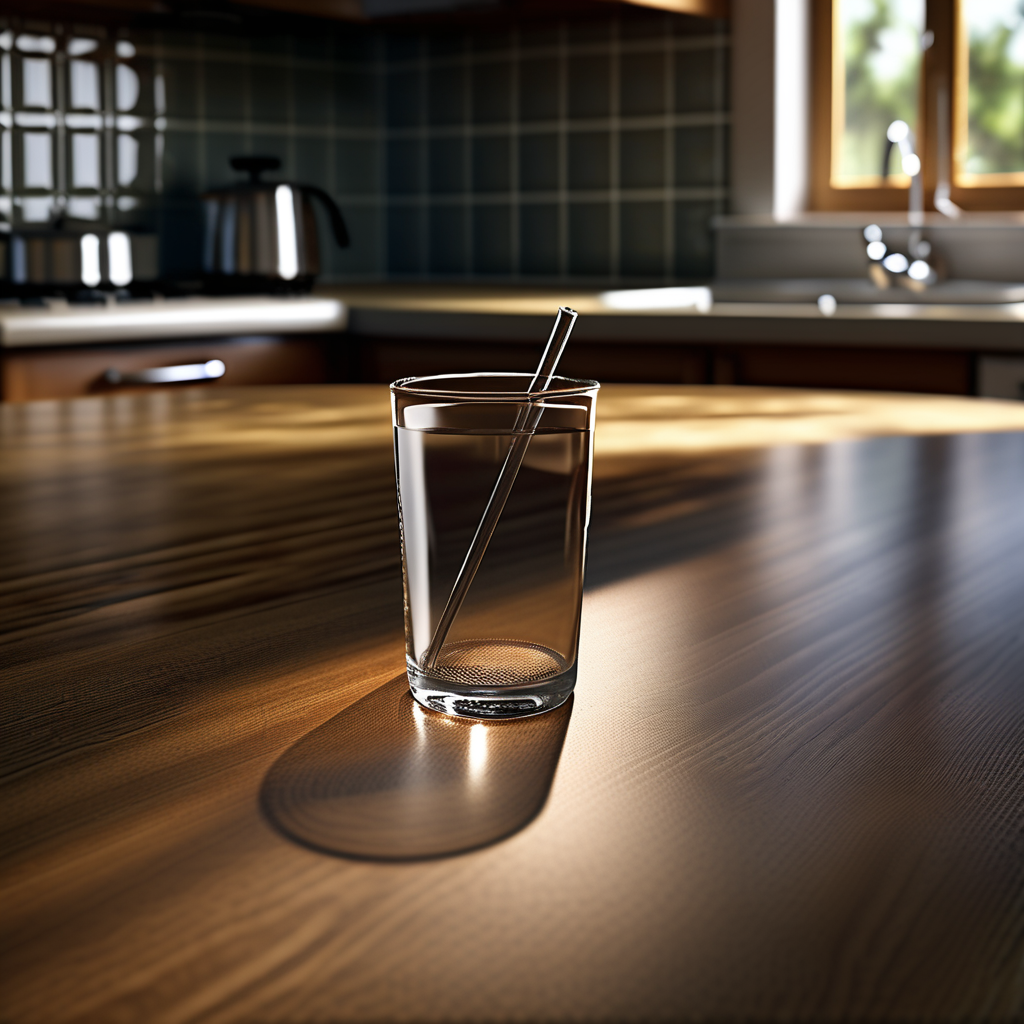

In [22]:
# Generate output
output = pipeln(
    prompt = prompt,
    negative_prompt = negative_prompt,
    control_image = [canny_image_can, depth_image, shadow_image, refract_image],
    control_mode = [0,1,0,2],
    controlnet_conditioning_scale = 0.7,
    guidance_scale = 22.5,
    num_inference_steps=100,
    control_guidance_start = 0,
    control_guidance_end = 0.9,
    generator = generator
).images

output[0]

In [13]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-99gnuxz_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-99gnuxz_
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=88fbd47bfd726fa9fbc39b211789b7cc14070f0af8496681e3660a3be157210d
  Stored in directory: /tmp/pip-ephem-wheel-cache-i91q79cl/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


In [23]:
# Scorer dependencies
import ImageReward as RM

# Load the ImageReward model
model = RM.load("ImageReward-v1.0")

# Get scores for image based on the prompt
rewards = model.score(prompt, output[0])

# Print the scores
rewards

load checkpoint from /root/.cache/ImageReward/ImageReward.pt
checkpoint loaded


0.8994330167770386